# PRCP-1006 - Home Loan Default - Risk Management  

## Objectives  

**1. Exploratory Data Analysis**  
Understand the dataset: shape, datatypes, ditribution, correlaltion, ,missing values etc.  
   
**2. Modelling and Interpretability**  
Build a robust model to predict the loan applicant is a probable defaulter or not.  

**Metrics**: Recall, Precision, F1-Score, ROC-AUC Score, PR-AUC Score  
**Dataset**: Loan Default Dataset  
.

## Import Libraries 

In [3]:
# core libraries
import os
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score, confusion_matrix

# count classes
from collections import Counter

# to free up RAM
import gc

# saving the model
import joblib

# pandas setup
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)

# warnings
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [2]:
app = pd.read_csv(os.path.join('Data', 'application_train.csv'))

## Exploratory Data Analysis

## Preview data

In [3]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
app.shape # numner of rows and columns

(307511, 122)

In [6]:
app.dtypes

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE               object
CODE_GENDER                      object
FLAG_OWN_CAR                     object
FLAG_OWN_REALTY                  object
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                  object
NAME_INCOME_TYPE                 object
NAME_EDUCATION_TYPE              object
NAME_FAMILY_STATUS               object
NAME_HOUSING_TYPE                object
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64


## Check missing values

In [7]:
# number of missing values in each column in descending order
app.isnull().sum().sort_values(ascending=False).head(70) 

COMMONAREA_MEDI                 214865
COMMONAREA_AVG                  214865
COMMONAREA_MODE                 214865
NONLIVINGAPARTMENTS_MODE        213514
NONLIVINGAPARTMENTS_AVG         213514
NONLIVINGAPARTMENTS_MEDI        213514
FONDKAPREMONT_MODE              210295
LIVINGAPARTMENTS_MODE           210199
LIVINGAPARTMENTS_AVG            210199
LIVINGAPARTMENTS_MEDI           210199
FLOORSMIN_AVG                   208642
FLOORSMIN_MODE                  208642
FLOORSMIN_MEDI                  208642
YEARS_BUILD_MEDI                204488
YEARS_BUILD_MODE                204488
YEARS_BUILD_AVG                 204488
OWN_CAR_AGE                     202929
LANDAREA_MEDI                   182590
LANDAREA_MODE                   182590
LANDAREA_AVG                    182590
BASEMENTAREA_MEDI               179943
BASEMENTAREA_AVG                179943
BASEMENTAREA_MODE               179943
EXT_SOURCE_1                    173378
NONLIVINGAREA_MODE              169682
NONLIVINGAREA_AVG        

In [8]:
# percentage of missing values in each column
app.isnull().mean().sort_values(ascending=False).head(70)*100 

COMMONAREA_MEDI                 69.872297
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

### Target variable analysis

In [9]:
app['TARGET'].value_counts(), app['TARGET'].value_counts(normalize=True)

(TARGET
 0    282686
 1     24825
 Name: count, dtype: int64,
 TARGET
 0    0.919271
 1    0.080729
 Name: proportion, dtype: float64)

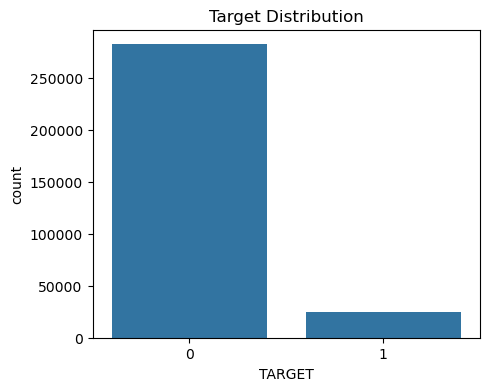

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=app)
plt.title("Target Distribution")
plt.show()

### Numerical feature summary

In [11]:
numeric_cols = app.select_dtypes(include=[np.number]).columns
app[numeric_cols].describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [12]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


### Categorical feature summary

In [13]:
cat_cols = app.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print("==========================")
    print(app[c].value_counts())

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816

## Anomaly check

In [77]:
for col in numeric_cols:
    print(app[col].value_counts().head())

SK_ID_CURR
100002    1
337664    1
337661    1
337660    1
337659    1
Name: count, dtype: int64
TARGET
0    282686
1     24825
Name: count, dtype: int64
CNT_CHILDREN
0    215371
1     61119
2     26749
3      3717
4       429
Name: count, dtype: int64
AMT_INCOME_TOTAL
135000.0    35750
112500.0    31019
157500.0    26556
180000.0    24719
90000.0     22483
Name: count, dtype: int64
AMT_CREDIT
450000.0    9709
675000.0    8877
225000.0    8162
180000.0    7342
270000.0    7241
Name: count, dtype: int64
AMT_ANNUITY
9000.0     6385
13500.0    5514
6750.0     2279
10125.0    2035
37800.0    1602
Name: count, dtype: int64
AMT_GOODS_PRICE
450000.0    26022
225000.0    25282
675000.0    24962
900000.0    15416
270000.0    11428
Name: count, dtype: int64
REGION_POPULATION_RELATIVE
0.035792    16408
0.046220    13442
0.030755    12163
0.025164    11950
0.026392    11601
Name: count, dtype: int64
DAYS_BIRTH
-13749    43
-13481    42
-18248    41
-10020    41
-15771    40
Name: count, dtype: int

In [16]:
app['DAYS_EMPLOYED'].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
Name: count, dtype: int64

DAYS_EMPLOYED feature has a value 365243 which has been used as a placeholder for missing values, can breaks the distribution, and leads to poor model performance.

In [23]:
# replacing 365243 with nan value
app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

### Feature vs Target (numeric)

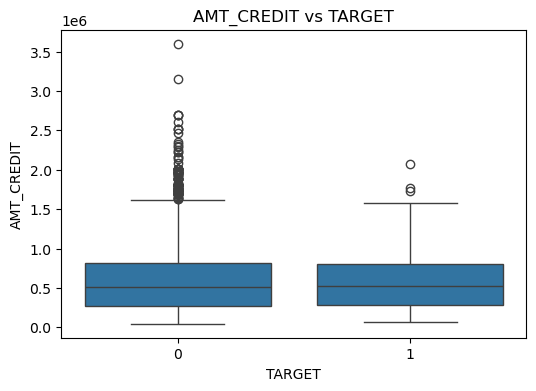

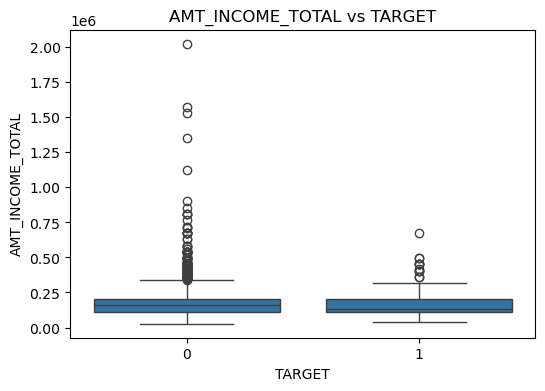

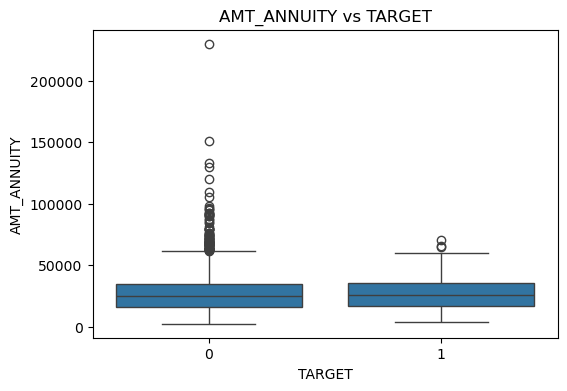

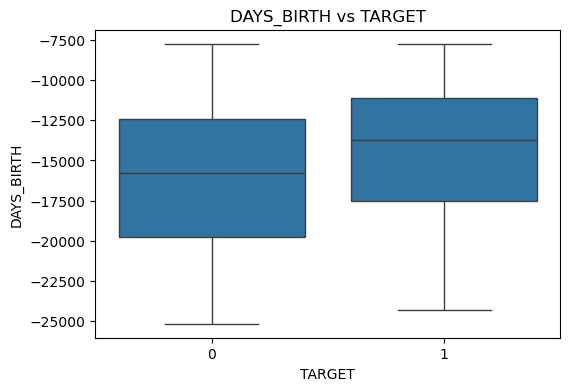

In [24]:
important_nums = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH']

for col in important_nums:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='TARGET', y=col, data=app.sample(5000, random_state=42))
    plt.title(f"{col} vs TARGET")
    plt.show()


### Features vs TARGET (categorical)

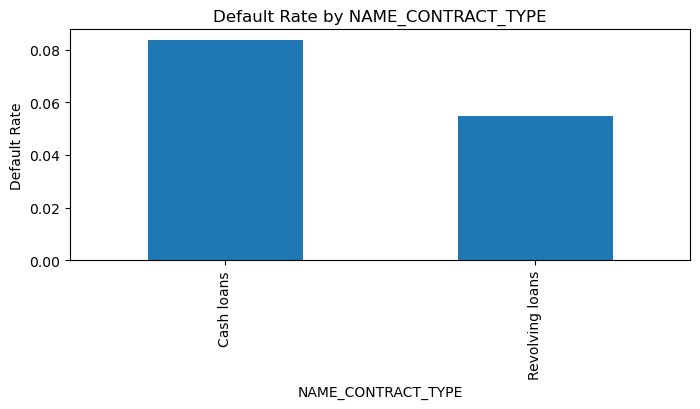

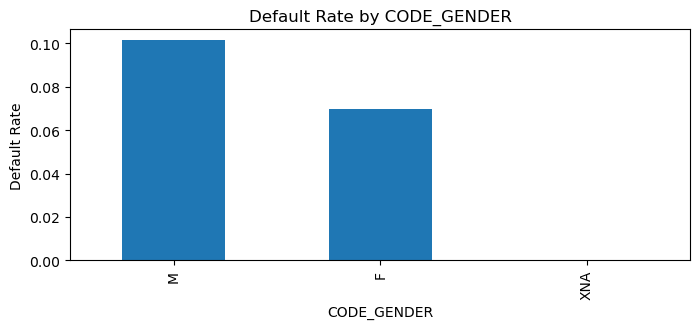

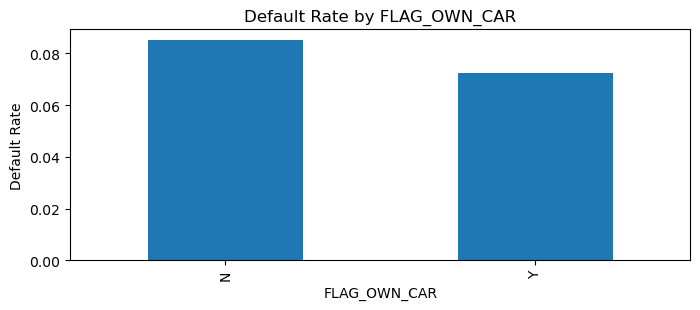

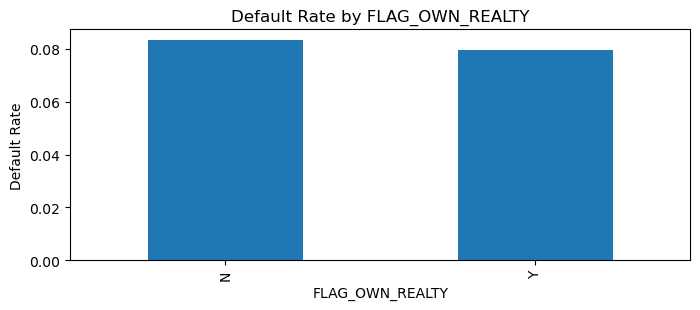

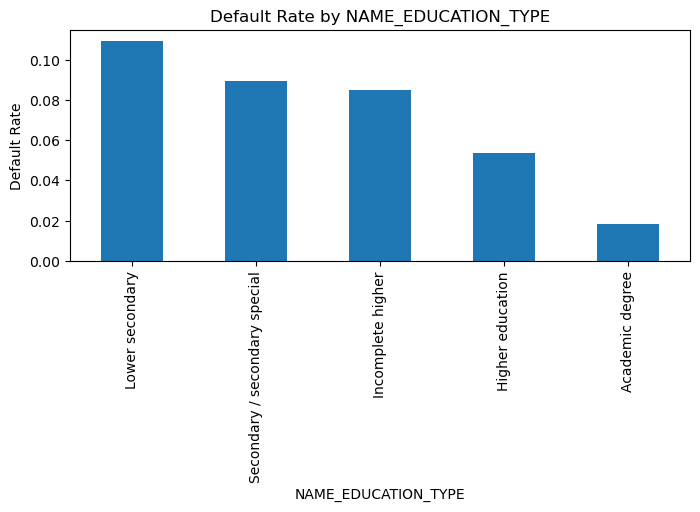

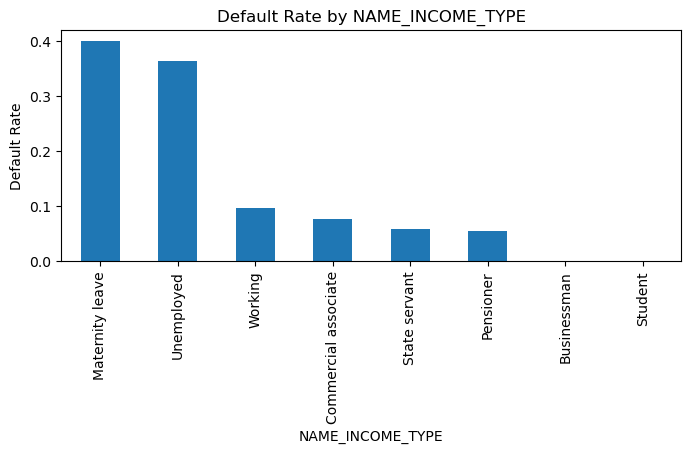

In [25]:
cat_check = ['NAME_CONTRACT_TYPE','CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
             'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']

for col in cat_check:
    plt.figure(figsize=(8,3))
    temp = app.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    temp.plot(kind='bar')
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.show()

### Correlation heatmap
Correlation of highly correlated 10 numerical features

TARGET                         1.000000
DAYS_BIRTH                     0.078239
DAYS_EMPLOYED                  0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
Name: TARGET, dtype: float64


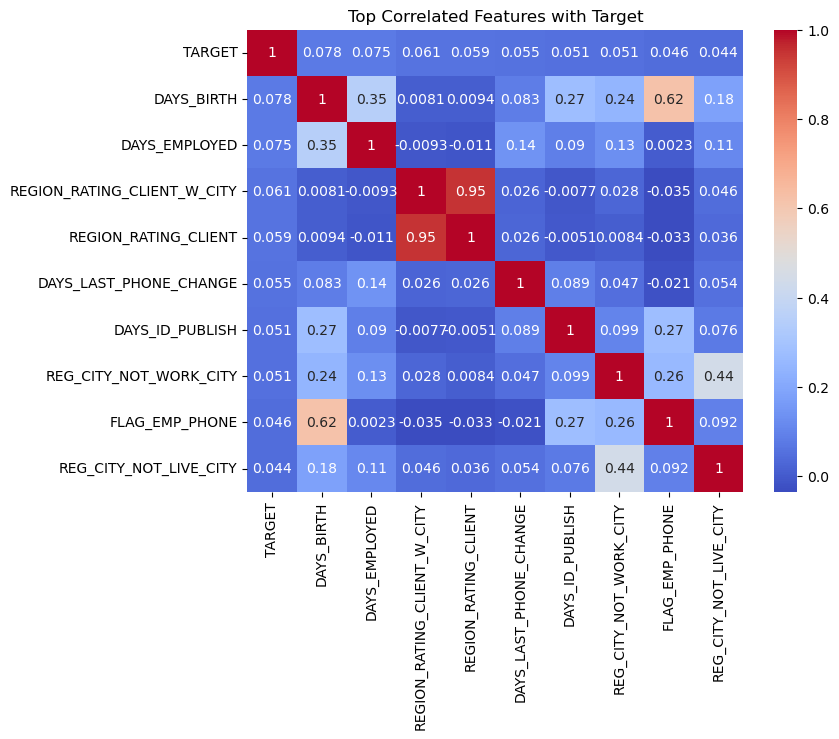

In [26]:
top_corr = app.corr(numeric_only=True)['TARGET'].sort_values(ascending=False).head(10)
print(top_corr)
plt.figure(figsize=(8,6))
sns.heatmap(app[top_corr.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Correlated Features with Target")
plt.show()

### Outlier detection

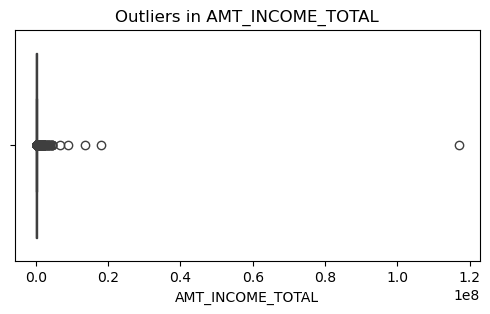

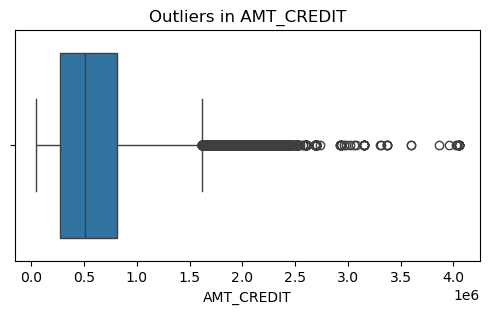

In [27]:
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=app[col])
    plt.title(f"Outliers in {col}")
    plt.show()

From the above box plots its clear that the dataset contains numerical features with outliers, since we are using tree-based models, outliers are not an issue. Tree models are almost completely insensitive to outliers.

### Basic EDA on auxillary datasets

#### Understanding the structure of datasets

```
application_train.csv      → 1 row per loan application
bureau.csv                 → many previous loans per customer
bureau_balance.csv         → monthly history per previous loan
POS_CASH_balance.csv       → POS/Cash loan monthly balance
credit_card_balance.csv    → monthly credit card balance
previous_application.csv   → previous loan applications by same customer
installments_payments.csv  → payment history per previous loan
```

```
SK_ID_CURR ──> 1 main record in application_train
         ├─> multiple rows in bureau (old loans)
         ├─> indirectly multiple rows in bureau_balance (linked via SK_ID_BUREAU)
         ├─> multiple rows in POS_CASH
         ├─> multiple rows in credit_card
         ├─> multiple rows in previous_application (old Home Credit loans)
         └─> multiple rows in installments_payments  
```

In [41]:
#Auxiliary tables
bureau = pd.read_csv(os.path.join('Data', 'bureau.csv'))
bureau_balance = pd.read_csv(os.path.join('Data', 'bureau_balance.csv'))
pos_cash = pd.read_csv(os.path.join('Data', 'POS_CASH_balance.csv'))
credit_card = pd.read_csv(os.path.join('Data', 'credit_card_balance.csv'))
prev_app = pd.read_csv(os.path.join('Data', 'previous_application.csv'))
installments = pd.read_csv(os.path.join('Data', 'installments_payments.csv'))

In [42]:
datasets = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": prev_app,
    "installments_payments": installments,
    "credit_card_balance": credit_card,
    "POS_CASH_balance": pos_cash
}
for name, df in datasets.items():
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes.value_counts())
    print("\nMissing Values (Top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("=======================================================")
    print("=======================================================")


DATASET: bureau
Shape: (1716428, 17)

Columns:
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Data Types:
float64    8
int64      6
object     3
Name: count, dtype: int64

Missing Values (Top 10):
AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
dtype: int64

DATASET: bureau_balance
Shape: (27299925, 3)

Columns:
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

Data Types:
int64     2
object    1
Name: count, dtype

### Relationship between Auxillary Dataset and SK_ID_CURR

In [39]:
for name, df in datasets.items():
    if 'SK_ID_CURR' in df.columns:
        counts = df['SK_ID_CURR'].value_counts()
        print(f"\n{name}: rows per customer")
        print(counts.describe())


bureau: rows per customer
count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: count, dtype: float64

previous_application: rows per customer
count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
Name: count, dtype: float64

installments_payments: rows per customer
count    339587.000000
mean         40.064552
std          41.053343
min           1.000000
25%          12.000000
50%          25.000000
75%          51.000000
max         372.000000
Name: count, dtype: float64

credit_card_balance: rows per customer
count    103558.000000
mean         37.083683
std          33.483627
min           1.000000
25%          10.000000
50%          22.000000
75%          75.000000
max         192.000000
Name: count, dtype: float64

P

### For bureau_balance (linked via SK_ID_BUREAU)

In [44]:
if 'SK_ID_BUREAU' in bureau_balance.columns:
    print("\nbureau_balance rows per SK_ID_BUREAU:")
    print(bureau_balance['SK_ID_BUREAU'].value_counts().describe())


bureau_balance rows per SK_ID_BUREAU:
count    817395.000000
mean         33.398693
std          25.794666
min           1.000000
25%          13.000000
50%          26.000000
75%          48.000000
max          97.000000
Name: count, dtype: float64


## Feature Enigneering -- Part 1

Auxiliary tables contain many records per customer, so directly merging them would explode the dataset and break the one-row-per-customer structure required for modeling.
Aggregation converts these multiple historical records into meaningful summary features (mean, max, sum, counts), making the data usable and strengthening predictive power.

### Creating Fuctions to Aggragate Dataset

#### Function to aggregate numerical features
The multiple historical records are turned into meaningful summary features like count, mean, max, min, sum, var along with an additional column for count of rows per grouping variable (SK_ID_CURR or SK_ID_BUREAU for bureau_balance)

In [8]:
# Aggregate numerical features in a dataset
def aggregate_numericals(df,group_var,df_name):
    # take all the numeric column
    numeric_df = df.select_dtypes(include=[np.number]) 
    
    # making sure group var is in the dataframe
    numeric_df[group_var] = df[group_var] 
    
    # performing numerical aggregation
    aggregated_df = numeric_df.groupby(group_var).agg(['count','mean','max','min','sum','var'])
    
    # columns of the aggregated dataframe are in tuple format and needs to be flattened
    aggregated_df.columns = [df_name + '_' + '_'.join(col) for col in aggregated_df.columns]
    
    # after aggregation the group_var column becomes the index which need to be put back as a column
    aggregated_df.reset_index(inplace = True)
    
    # add a column for total count of rows per group_var
    group_counts = df.groupby(group_var).size().reset_index(name=f"{df_name}_GROUP_COUNT")

    # Merge the count column into the aggregated result
    aggregated_df = aggregated_df.merge(group_counts, on=group_var, how='left')
    
    return aggregated_df

#### Function to aggregate categorical features
This function aggregates by counting how often each category appears for each customer

In [13]:
# Aggregate categorical features by counting how often each category appears for each customer
def aggregate_categoricals(df, id_col, df_name):
  
    # Work on a copy
    df_cat = df.copy()
    
    # Identify categorical/object columns only (exclude numeric + id)
    cat_cols = [c for c in df_cat.columns 
                if (df_cat[c].dtype == 'object' or df_cat[c].dtype.name == 'category') 
                and c != id_col]
    
    if not cat_cols:
        print("No categorical columns found — returning ID column only.")
        return df_cat[[id_col]].drop_duplicates()
    
    # Keep only id + categorical columns
    df_cat = df_cat[[id_col] + cat_cols]
    
    # One-hot encode
    df_cat = pd.get_dummies(df_cat, columns=cat_cols, dummy_na=True, dtype='int8')
    
    # Group by id and sum counts
    df_agg = df_cat.groupby(id_col, as_index=False).sum()
    
    # Add prefix if provided
    if df_name:
        df_agg.columns = [id_col] + [f"{df_name}_{col}" for col in df_agg.columns if col != id_col]
    
    return df_agg


### Aggregating datasets

#### Aggregating bureau_balace

In [25]:
bureau_balance = pd.read_csv(os.path.join('Data','bureau_balance.csv'))

In [26]:
bureau_balance_agg_num = aggregate_numericals(bureau_balance,'SK_ID_BUREAU','bureau_balance')
bureau_balance_agg_cat = aggregate_categoricals(bureau_balance,'SK_ID_BUREAU','bureau_balance')
bureau_balance_agg = bureau_balance_agg_num.merge(bureau_balance_agg_cat, on='SK_ID_BUREAU', how='left')

In [27]:
bureau_balance_agg.to_csv("bureau_balance_agg.csv", index=False)

In [33]:
# deleting temporary dataframes to prevent memory error
del bureau_balance, bureau_balance_agg, bureau_balance_agg_num, bureau_balance_agg_cat
gc.collect()

0

#### Aggregating POS_CASH_balance

In [43]:
pos_cash = pd.read_csv(os.path.join('Data','POS_CASH_balance.csv'))

In [48]:
pos_cash.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [49]:
pos_cash_2 = pos_cash.drop(columns=['SK_ID_PREV'], errors='ignore') # dropping irrelevant column

In [52]:
pos_cash_agg_num = aggregate_numericals(pos_cash_2,'SK_ID_CURR','pos_cash')
pos_cash_agg_cat = aggregate_categoricals(pos_cash_2,'SK_ID_CURR','pos_cash')
pos_cash_agg = pos_cash_agg_num.merge(pos_cash_agg_cat, on='SK_ID_CURR', how='left')

In [53]:
pos_cash_agg.to_csv("pos_cash_agg.csv", index=False)

In [54]:
del pos_cash, pos_cash_2, pos_cash_agg_num, pos_cash_agg_cat, pos_cash_agg
gc.collect()

1803

#### Aggregating credit_card_balance

In [55]:
credit_card = pd.read_csv(os.path.join('Data','credit_card_balance.csv'))

In [56]:
credit_card.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [57]:
credit_card_2 = credit_card.drop(columns=['SK_ID_PREV'], errors='ignore') # dropping irrelevant column

In [60]:
credit_card_agg_num = aggregate_numericals(credit_card_2,'SK_ID_CURR','credit_card')
credit_card_agg_cat = aggregate_categoricals(credit_card_2,'SK_ID_CURR','credit_card')
credit_card_agg = credit_card_agg_num.merge(credit_card_agg_cat, on='SK_ID_CURR', how='left')

In [62]:
credit_card_agg.to_csv("credit_card_agg.csv", index=False)

In [63]:
del credit_card, credit_card_2, credit_card_agg_num, credit_card_agg_cat, credit_card_agg
gc.collect()

0

#### Aggregating previous_application

In [64]:
prev_app = pd.read_csv(os.path.join('Data','previous_application.csv'))

In [71]:
prev_app.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [66]:
prev_app_2 = prev_app.drop(columns=['SK_ID_PREV'], errors='ignore') # dropping irrelevant column

In [68]:
prev_app_agg_num = aggregate_numericals(prev_app_2,'SK_ID_CURR','prev_app')
prev_app_agg_cat = aggregate_categoricals(prev_app_2,'SK_ID_CURR','prev_app')
prev_app_agg = prev_app_agg_num.merge(prev_app_agg_cat, on='SK_ID_CURR', how='left')

In [69]:
prev_app_agg.to_csv("prev_app_agg.csv", index=False)

In [72]:
del prev_app, prev_app_2, prev_app_agg_num, prev_app_agg_cat, prev_app_agg
gc.collect()

0

#### Aggregating installments_payments

In [73]:
installments = pd.read_csv(os.path.join('Data','installments_payments.csv'))

In [78]:
installments.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='object')

In [76]:
installments_2 = installments.drop(columns=['SK_ID_PREV'], errors='ignore') # dropping irrelevant column

In [79]:
installments_agg_num = aggregate_numericals(installments_2,'SK_ID_CURR','installments')
installments_agg_cat = aggregate_categoricals(installments_2,'SK_ID_CURR','installments')
installments_agg = installments_agg_num.merge(installments_agg_cat, on='SK_ID_CURR', how='left')

No categorical columns found — returning ID column only.


In [80]:
installments_agg.to_csv("installments_agg.csv", index=False)

In [82]:
del installments, installments_2, installments_agg, installments_agg_num, installments_agg_cat
gc.collect()

0

#### Aggregating bureau

In [90]:
bureau = pd.read_csv(os.path.join('Data','bureau.csv'))

Before aggregating bureau we need to merge bureau_balance_agg with bureau using SK_ID_BUREAU

In [92]:
bureau_balance_agg = pd.read_csv('bureau_balance_agg.csv')

In [93]:
# Merge the aggregated bureau balance features with bureau
bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')

In [95]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY', 'bureau_balance_MONTHS_BALANCE_count',
       'bureau_balance_MONTHS_BALANCE_mean',
       'bureau_balance_MONTHS_BALANCE_max',
       'bureau_balance_MONTHS_BALANCE_min',
       'bureau_balance_MONTHS_BALANCE_sum',
       'bureau_balance_MONTHS_BALANCE_var', 'bureau_balance_GROUP_COUNT',
       'bureau_balance_STATUS_0', 'bureau_balance_STATUS_1',
       'bureau_balance_STATUS_2', 'bureau_balance_STATUS_3',
       'bureau_balance_STATUS_4', 'bureau_balance_STATUS_5',
       'bureau_balance_STATUS_C', 'bureau_balance_STATUS_X',
       'bureau_balance_STATUS_nan'],
      dtype='object')

In [96]:
bureau_2 = bureau.drop(columns=['SK_ID_BUREAU'], errors='ignore') # dropping irrelevant column

In [98]:
bureau_agg_num = aggregate_numericals(bureau_2,'SK_ID_CURR','bureau')
bureau_agg_cat = aggregate_categoricals(bureau_2,'SK_ID_CURR','bureau')
bureau_agg = bureau_agg_num.merge(bureau_agg_cat, on='SK_ID_CURR', how='left')

In [99]:
bureau_agg.to_csv("bureau_agg.csv", index=False)

In [100]:
del bureau, bureau_2, bureau_balance_agg, bureau_agg_num, bureau_agg_cat, bureau_agg
gc.collect()

45

### Merging all aggregated datasets to parent dataset (application_train)

In [101]:
app = pd.read_csv(os.path.join('Data','application_train.csv'))

In [105]:
app.shape

(307511, 122)

In [114]:
app_train = app.copy()
print("Shape of application_train ",app.shape)
# List all aggregated datasets
agg_files = [
    "bureau_agg.csv",
    "pos_cash_agg.csv",
    "credit_card_agg.csv",
    "prev_app_agg.csv",
    "installments_agg.csv",   
]
# Loop and merge one file at a time
for file in agg_files:
    print(f"Merging {file}...")
    temp = pd.read_csv(file)          # load aggregated file
    print(f"Shape of {file} ",temp.shape)
    app_train = app_train.merge(temp, on="SK_ID_CURR", how="left")  # left join
    del temp                          # delete temp DataFrame
    gc.collect()                      # free memory
    print(f"{file} merged successfully")

Shape of application_train  (307511, 122)
Merging bureau_agg.csv...
Shape of bureau_agg.csv  (305811, 196)
bureau_agg.csv merged successfully
Merging pos_cash_agg.csv...
Shape of pos_cash_agg.csv  (337252, 42)
pos_cash_agg.csv merged successfully
Merging credit_card_agg.csv...
Shape of credit_card_agg.csv  (103558, 130)
credit_card_agg.csv merged successfully
Merging prev_app_agg.csv...
Shape of prev_app_agg.csv  (338857, 275)
prev_app_agg.csv merged successfully
Merging installments_agg.csv...
Shape of installments_agg.csv  (339587, 38)
installments_agg.csv merged successfully


In [115]:
app_train.shape

(307511, 798)

### Saving the final merged data

In [116]:
app_train.to_csv("final_merged_data.csv", index=False)

## Final merged Dataset

In [5]:
df = pd.read_csv('final_merged_data.csv') # reading the final merged dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 798 entries, SK_ID_CURR to installments_GROUP_COUNT
dtypes: float64(741), int64(41), object(16)
memory usage: 1.8+ GB


In [6]:
df.shape

(307511, 798)

In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_DAYS_CREDIT_count,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_sum,bureau_DAYS_CREDIT_var,bureau_CREDIT_DAY_OVERDUE_count,bureau_CREDIT_DAY_OVERDUE_mean,bureau_CREDIT_DAY_OVERDUE_max,bureau_CREDIT_DAY_OVERDUE_min,bureau_CREDIT_DAY_OVERDUE_sum,bureau_CREDIT_DAY_OVERDUE_var,bureau_DAYS_CREDIT_ENDDATE_count,bureau_DAYS_CREDIT_ENDDATE_mean,bureau_DAYS_CREDIT_ENDDATE_max,bureau_DAYS_CREDIT_ENDDATE_min,bureau_DAYS_CREDIT_ENDDATE_sum,bureau_DAYS_CREDIT_ENDDATE_var,bureau_DAYS_ENDDATE_FACT_count,bureau_DAYS_ENDDATE_FACT_mean,bureau_DAYS_ENDDATE_FACT_max,bureau_DAYS_ENDDATE_FACT_min,bureau_DAYS_ENDDATE_FACT_sum,bureau_DAYS_ENDDATE_FACT_var,bureau_AMT_CREDIT_MAX_OVERDUE_count,bureau_AMT_CREDIT_MAX_OVERDUE_mean,bureau_AMT_CREDIT_MAX_OVERDUE_max,bureau_AMT_CREDIT_MAX_OVERDUE_min,bureau_AMT_CREDIT_MAX_OVERDUE_sum,bureau_AMT_CREDIT_MAX_OVERDUE_var,bureau_CNT_CREDIT_PROLONG_count,bureau_CNT_CREDIT_PROLONG_mean,bureau_CNT_CREDIT_PROLONG_max,bureau_CNT_CREDIT_PROLONG_min,bureau_CNT_CREDIT_PROLONG_sum,bureau_CNT_CREDIT_PROLONG_var,bureau_AMT_CREDIT_SUM_count,bureau_AMT_CREDIT_SUM_mean,bureau_AMT_CREDIT_SUM_max,bureau_AMT_CREDIT_SUM_min,bureau_AMT_CREDIT_SUM_sum,bureau_AMT_CREDIT_SUM_var,bureau_AMT_CREDIT_SUM_DEBT_count,bureau_AMT_CREDIT_SUM_DEBT_mean,bureau_AMT_CREDIT_SUM_DEBT_max,bureau_AMT_CREDIT_SUM_DEBT_min,bureau_AMT_CREDIT_SUM_DEBT_sum,bureau_AMT_CREDIT_SUM_DEBT_var,bureau_AMT_CREDIT_SUM_LIMIT_count,bureau_AMT_CREDIT_SUM_LIMIT_mean,bureau_AMT_CREDIT_SUM_LIMIT_max,bureau_AMT_CREDIT_SUM_LIMIT_min,bureau_AMT_CREDIT_SUM_LIMIT_sum,bureau_AMT_CREDIT_SUM_LIMIT_var,bureau_AMT_CREDIT_SUM_OVERDUE_count,bureau_AMT_CREDIT_SUM_OVERDUE_mean,bureau_AMT_CREDIT_SUM_OVERDUE_max,bureau_AMT_CREDIT_SUM_OVERDUE_min,bureau_AMT_CREDIT_SUM_OVERDUE_sum,bu

## Feature Engineering - Part 2 

### Feature Creation

In [7]:
# Feature creation by taking ratio of important features
df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
df["CREDIT_TO_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

In [8]:
df.shape

(307511, 801)

### Dropping ID column

In [9]:
df = df.drop(columns=['SK_ID_CURR'], errors='ignore')

### Missing values

In [12]:
# number of missing values in each column in descending order
df.isnull().sum().sort_values(ascending=False).head(10) 

prev_app_RATE_INTEREST_PRIVILEGED_var       307337
prev_app_RATE_INTEREST_PRIMARY_var          307337
prev_app_RATE_INTEREST_PRIVILEGED_min       302902
prev_app_RATE_INTEREST_PRIVILEGED_max       302902
prev_app_RATE_INTEREST_PRIVILEGED_mean      302902
prev_app_RATE_INTEREST_PRIMARY_min          302902
prev_app_RATE_INTEREST_PRIMARY_max          302902
prev_app_RATE_INTEREST_PRIMARY_mean         302902
credit_card_AMT_PAYMENT_CURRENT_var         246892
credit_card_AMT_DRAWINGS_POS_CURRENT_var    246818
dtype: int64

The final merged dataset contains high amount of missing value, which has to be imputed.

## Model Building

### Features and target

In [10]:
X = df.drop(['TARGET'], axis=1)
y = df['TARGET']
print(X.shape)
print(y.shape)

(307511, 799)
(307511,)


In [8]:
# defining numerical and categorical columns
num_cols = list(X.select_dtypes(include=['int64', 'float64']).columns)
cat_cols = list(X.select_dtypes(include=['object', 'category']).columns)

### Train-Test split

In [11]:
# X, y are your features and target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% test set (common)
    stratify=y,             # keeps class ratio
    random_state=42
)

In [12]:
# freeing irrelevanat dataframes
del X,y, df
gc.collect()

0

### Configuring column transformer for pipeline

In [12]:
# Preprocessing
preprocess = ColumnTransformer([
    ('num', Pipeline([
        #imputing missing values in numerical columns
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()) # handles heavy skew
    ]), num_cols),
    
    ('cat', Pipeline([
        # imputing missing values in categorical columns
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')), 
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

### Compute Class Imbalance Ratio for XGBoost and LightGBM

In [13]:
counter = Counter(y_train)
neg = counter[0]
pos = counter[1]

scale_pos_weight = neg / pos
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 11.38710976837865


In [14]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=500),
    "Random Forest": RandomForestClassifier(class_weight='balanced_subsample'), 
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight)
}

### Function to evaluate model performcance

In [15]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, probas)
    pr_auc = average_precision_score(y_test, probas)

    print(f"\n===== {name} =====")
    print("ROC-AUC:", round(auc, 4))
    print("PR-AUC:", round(pr_auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

### Model training and Comparison

In [16]:
fitted_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    # Building the pipeline
    model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])
    model.fit(X_train, y_train)
    fitted_models[name] = model
    evaluate_model(name, model, X_test, y_test)

Training Logistic Regression...

===== Logistic Regression =====
ROC-AUC: 0.5467
PR-AUC: 0.1011

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.59      0.72     56538
           1       0.10      0.49      0.16      4965

    accuracy                           0.58     61503
   macro avg       0.51      0.54      0.44     61503
weighted avg       0.86      0.58      0.68     61503

Training Random Forest...

===== Random Forest =====
ROC-AUC: 0.7251
PR-AUC: 0.2016

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.57      0.00      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503

Training XGBoost...

===== XGBoost =====
ROC-AUC: 0.7679
PR-AUC: 0.2607

Classification Report:
              precisio

**Out of all models trained the lightGBM model has the highest PR-AUC Score.  
Therefore lightGBM model has been selected as the best model and will undergo hyperparameter tuning.**

## Saving all trained models

In [18]:
for name, model in fitted_models.items():
    filename = f"{name}.joblib"
    joblib.dump(model, filename)
    print(f"Saved {name} to {filename}")

Saved Logistic Regression to Logistic Regression.joblib
Saved Random Forest to Random Forest.joblib
Saved XGBoost to XGBoost.joblib
Saved LightGBM to LightGBM.joblib


## Threshold tuning

### Loading the LightGBM model (Best)

In [4]:
LGB_model = joblib.load("LightGBM.joblib")

In [20]:
y_probs = LGB_model.predict_proba(X_test)

In [24]:
y_probs.shape

(61503, 2)

In [31]:
# Predict probabilities
y_probs = LGB_model.predict_proba(X_test)[:, 1]  # probability of class 1 (default)

In [32]:
# Get precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

In [56]:
#applying business constraint
# Suppose we want recall >= 0.7 (catch at least 70% of defaults)
idx = np.where(recall >= 0.7)[0]  # indices satisfying recall constraint

# Choose threshold that maximizes precision under this constraint
best_idx = idx[np.argmax(precision[idx])]
best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)

Best threshold: 0.5021455040475794


In [57]:
# Apply threshold to make predictions
y_pred_tuned = (y_probs >= best_threshold).astype(int)

# Evaluate
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

[[41175 15363]
 [ 1489  3476]]
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     56538
           1       0.18      0.70      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503



#### **Note: Banks usually prioritize Recall of Defaulters**  

Missing a defaulter (false negative) means loan loss, which is costly.  
Rejecting a good customer (false positive) is less risky than approving a defaulter.
Precision of defaulter is secondary, we dont want too many false alarms.  
Metrics of non-defulaters is less critical.  

## Interpretation using feature importance

In [24]:
# Access the last step in the pipeline
lgb_model = LGB_model.named_steps['model'] 

importance_gain = lgb_model.feature_importances_  # underscore at the end!

transformed_features = LGB_model.named_steps['preprocess'].get_feature_names_out()


importance_df = pd.DataFrame({
    'feature': transformed_features,
    'importance_gain': importance_gain
}).sort_values(by='importance_gain', ascending=False)

print(importance_df)

                                               feature  importance_gain
780                                  num__PAYMENT_RATE              141
27                                   num__EXT_SOURCE_1              107
28                                   num__EXT_SOURCE_2               88
6                                      num__DAYS_BIRTH               71
29                                   num__EXT_SOURCE_3               67
7                                   num__DAYS_EMPLOYED               59
3                                     num__AMT_ANNUITY               54
776                  num__installments_AMT_PAYMENT_min               51
777                  num__installments_AMT_PAYMENT_sum               49
9                                 num__DAYS_ID_PUBLISH               41
2                                      num__AMT_CREDIT               40
118                num__bureau_DAYS_CREDIT_ENDDATE_max               35
782                             num__ANNUITY_TO_INCOME          

In [27]:
importance_df.head(15)

,feature,importance_gain
780,num__PAYMENT_RATE,141
27,num__EXT_SOURCE_1,107
28,num__EXT_SOURCE_2,88
6,num__DAYS_BIRTH,71
29,num__EXT_SOURCE_3,67
7,num__DAYS_EMPLOYED,59
3,num__AMT_ANNUITY,54
776,num__installments_AMT_PAYMENT_min,51
777,num__installments_AMT_PAYMENT_sum,49
9,num__DAYS_ID_PUBLISH,41


## Insights

**1. PAYMENT_RATE is the strongest predictor of default**  
num__PAYMENT_RATE has the highest gain score (141).
Lower payment rates = higher default risk. People who commit to very small installment payments are more risky.  

**2. Borrower reliability scores (EXT_SOURCE_1/2/3) are critical** 
External credit scoring is more predictive of default than many financial variables.  

**3. Age and Employment stability matter**  
DAYS_BIRTH (age) and DAYS_EMPLOYED (tenure) also rank highly
Younger customers tend to have higher default rates.
Less employment history also increases risk.  

**4. Repayment history from previous loans (installment features) is highly predictive.**  
Features like num__installments_AMT_PAYMENT_min and num__installments_AMT_PAYMENT_sum indicate prior repayment behavior. Borrowers who previously paid on time and consistently are less likely to default again.
.

## Challenges Faced

**1. Extremely large and multi-table dataset**  
Handling this volume caused memory issues, required cleaning of unused variables and aggregation. 

**2. Complex data relationships**
Each client had multiple previous loans, monthly histories, and credit bureau records.
Merging and aggregating these into a single training table required careful join keys and aggregation logic. 

**3. Heavy preprocessing requirements**  
aggregation, anomaly replacement, missing value imputation, scaling etc

**4. High class imbalance**    
The dataset is extremely imbalanced (~9% defaults).
Choosing the right strategy (class weights, balanced boosting, threshold tuning) was challenging to avoid a biased model.  

**5. Feature engineering complexity**  
Creating meaningful features such as PAYMENT_RATE, ANNUITY_TO_INCOME, CREDIT_TO_INCOME.    

**6. Long training times for models**    
Models like LightGBM, XGBoost, Random Forest took significant time to train due to High dimensionality.  

**7. Deciding the correct evaluation metric**   
Accuracy was misleading due to imbalance. Choosing AUC-ROC, precision-recall, and threshold optimization was crucial.  

**8. Ensuring consistent preprocessing for inference**   
Pipeline-based processing needed to remember encoding categories, scaling.    